In [1]:
%run init_notebook.py
import sys
sys.path.append('src')

import os
import torch
import torch.optim as optim
import torchaudio.transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

from src.dataset import NSynth, nsynth_collate_fn
from src.models2 import ConditionalVAE
from src.losses import MultiDecoderLoss

In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"listos en: {DEVICE}")

EPOCHS = 50
BATCH_SIZE = 16
LR = 1e-4

os.makedirs("checkpoints", exist_ok=True)

# Cargamos el dataset pidiendo que solo traiga los que tienen el .pt extraído
print("Cargando dataset...")
ds = NSynth('training', require_features=True)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=nsynth_collate_fn, num_workers=2)

# Transformación al vuelo a Mel-spec
mel_transform = T.MelSpectrogram(
    sample_rate=16000, 
    n_fft=1024, 
    hop_length=160, 
    n_mels=80
).to(DEVICE)

listos en: cuda
Cargando dataset...
Carga completada: 289205 muestras de todos los instrumentos.


In [3]:
# El modelo híbrido
model = ConditionalVAE(channels=[1, 32, 64, 128, 256]).to(DEVICE)

# La loss: beta_max lo ponemos en 0.1 y que tarde un par de epochs en alcanzarlo
loss_fn = MultiDecoderLoss(beta_max=0.1, beta_steps=len(loader)*5).to(DEVICE) 

optimizer = optim.Adam(model.parameters(), lr=LR)

# Listas para guardar el historial y pintarlo luego
history = {'total': [], 'mel': [], 'ddsp': [], 'kld': []}

In [4]:
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    
    # Barra de progreso integrada en el notebook
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch in pbar:
        # 1. Desempaquetar
        waveforms, srs, keys, metadatas, features, conditions = batch
        
        # 2. Subir a GPU
        waveforms = waveforms.to(DEVICE)
        f0_real = features['f0'].to(DEVICE)
        loudness_real = features['loudness_db'].to(DEVICE)
        
        inst_oh = conditions['instrument_onehot'].to(DEVICE)
        pitch_n = conditions['pitch_norm'].to(DEVICE)
        vel_n = conditions['velocity_norm'].to(DEVICE)
        bright = conditions['brightness'].to(DEVICE)
        sustain = conditions['sustain'].to(DEVICE)

        # 3. Audio a Mel (y lo recortamos a 128 frames)
        mel_orig = mel_transform(waveforms)
        mel_orig = mel_orig[:, :, :, :128]
        
        # Empaquetamos features reales para la loss
        features_real = {'f0': f0_real, 'loudness_db': loudness_real}

        # --- FORWARD ---
        optimizer.zero_grad()
        mel_hat, ddsp_params, kld = model(mel_orig, inst_oh, pitch_n, vel_n, bright, sustain)
        
        # --- CÁLCULO DEL ERROR ---
        loss, loss_dict = loss_fn(mel_orig, mel_hat, ddsp_params, features_real, kld)

        # --- BACKWARD ---
        loss.backward()
        optimizer.step()
        loss_fn.step_beta() # Aumentar el KLD poco a poco

        # --- LOGGING ---
        epoch_loss += loss.item()
        
        # Guardamos en el historial cada 50 steps para que la gráfica tenga buena resolución
        if loss_fn.current_step % 50 == 0:
            history['total'].append(loss_dict['loss'])
            history['mel'].append(loss_dict['mel'])
            history['ddsp'].append(loss_dict['ddsp'])
            history['kld'].append(loss_dict['kld'])

        pbar.set_postfix({
            'L': f"{loss_dict['loss']:.3f}",
            'Mel': f"{loss_dict['mel']:.3f}", 
            'DDSP': f"{loss_dict['ddsp']:.3f}"
        })

    print(f"Epoch {epoch+1} terminada. Loss media: {epoch_loss/len(loader):.4f}")
    
    # Guardamos checkpoint
    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f"checkpoints/cvae_epoch_{epoch+1}.pt")

Epoch 1/50: 100%|██████████| 18076/18076 [39:00<00:00,  7.72it/s, L=824.751, Mel=247.682, DDSP=0.125]          


Epoch 1 terminada. Loss media: 7208.2436


Epoch 2/50: 100%|██████████| 18076/18076 [15:16<00:00, 19.73it/s, L=303.632, Mel=189.892, DDSP=0.125]    


Epoch 2 terminada. Loss media: 10959.5388


Epoch 3/50: 100%|██████████| 18076/18076 [14:21<00:00, 20.98it/s, L=278.304, Mel=91.962, DDSP=0.030]     


...

Epoch 48 terminada. Loss media: 12449.2168


Epoch 49/50: 100%|██████████| 18076/18076 [30:15<00:00,  9.96it/s, L=707.517, Mel=109.791, DDSP=0.026]    


Epoch 49 terminada. Loss media: 27265.0608


Epoch 50/50: 100%|██████████| 18076/18076 [27:01<00:00, 11.15it/s, L=1234.541, Mel=190.516, DDSP=0.013]   

Epoch 50 terminada. Loss media: 21789.3493


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

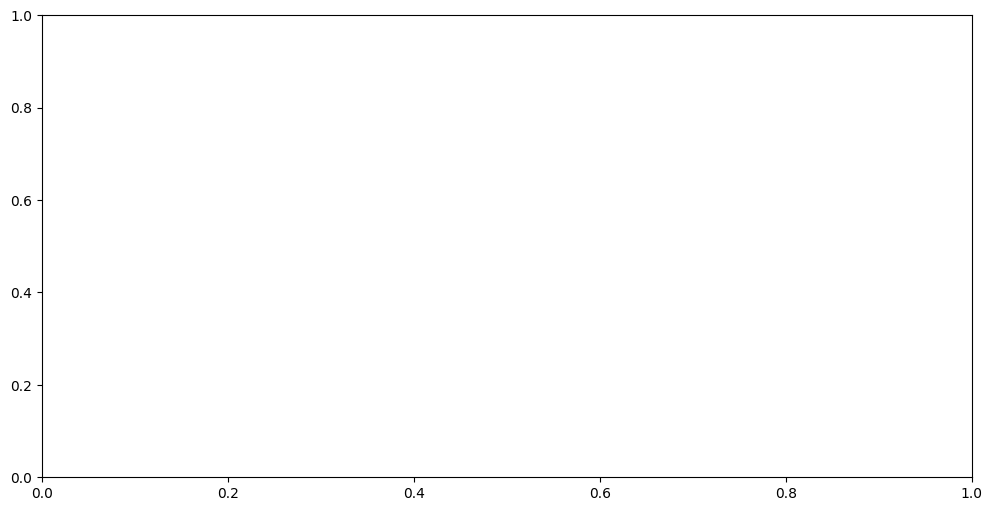

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(history['total'], label='Loss Total', color='black', linewidth=2)
plt.plot(history['mel'], label='Loss Mel (Espectrograma)', alpha=0.8)
plt.plot(history['ddsp'], label='Loss DDSP (f0 + Loudness)', alpha=0.8)
plt.plot(history['kld'], label='Loss KLD (Espacio Latente)', alpha=0.8, linestyle='--')

plt.title('Evolución del Entrenamiento CVAE')
plt.xlabel('Steps (x50)')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log') # Escala logarítmica suele verse mejor para losses
plt.show()